In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import figure
from datetime import datetime, timedelta

In [86]:
df = pd.read_csv("../data/main_data.csv")

# Clleaning data & formating it

In [87]:
df = df.dropna(subset=["CustomerID"]).copy()

df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()
df["UnitPrice"] = pd.to_numeric(
    df["UnitPrice"].astype(str).str.replace(",", ".", regex=False),
    errors="raise",
)

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df = df.drop_duplicates()

df.info()

/tmp/ipykernel_81995/3062030550.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()


<class 'pandas.DataFrame'>
Index: 392691 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392691 non-null  str           
 1   StockCode    392691 non-null  str           
 2   Description  392691 non-null  str           
 3   Quantity     392691 non-null  int64         
 4   InvoiceDate  392691 non-null  datetime64[us]
 5   UnitPrice    392691 non-null  float64       
 6   CustomerID   392691 non-null  int64         
 7   Country      392691 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 27.0 MB


In [88]:
nominal = df[["InvoiceDate", "StockCode", "Description","CustomerID", "Country"]]
ordinal = df[["InvoiceDate"]]
discrete = df[["Quantity"]]
continuous = df[["UnitPrice"]]

# Data visualization

### Customers per country

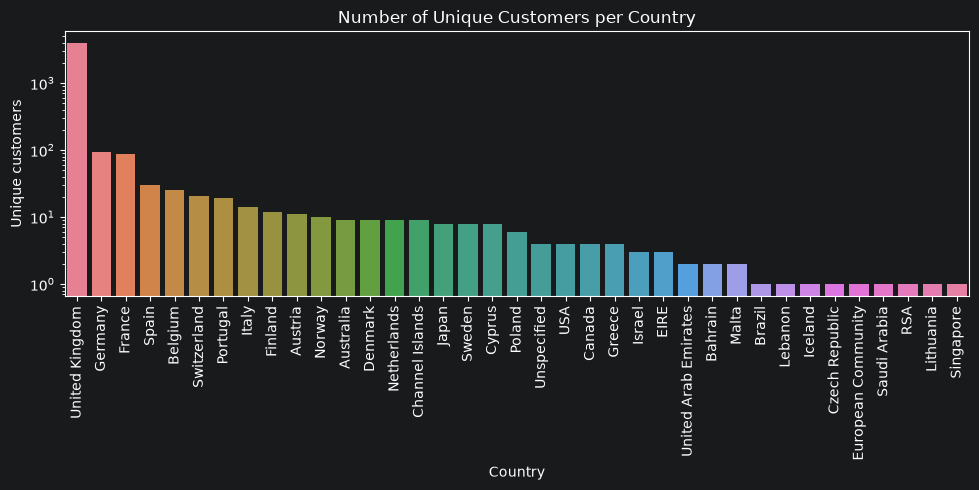

In [89]:
cust_per_country = (
    df.groupby("Country")["CustomerID"]
      .nunique()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=cust_per_country.index, y=cust_per_country.values,
            hue=cust_per_country.index, legend=False)
plt.title("Number of Unique Customers per Country")
plt.ylabel("Unique customers")
plt.xlabel("Country")
plt.xticks(rotation=90)
plt.tight_layout()
plt.yscale("log")
plt.show()

### Sales per countery

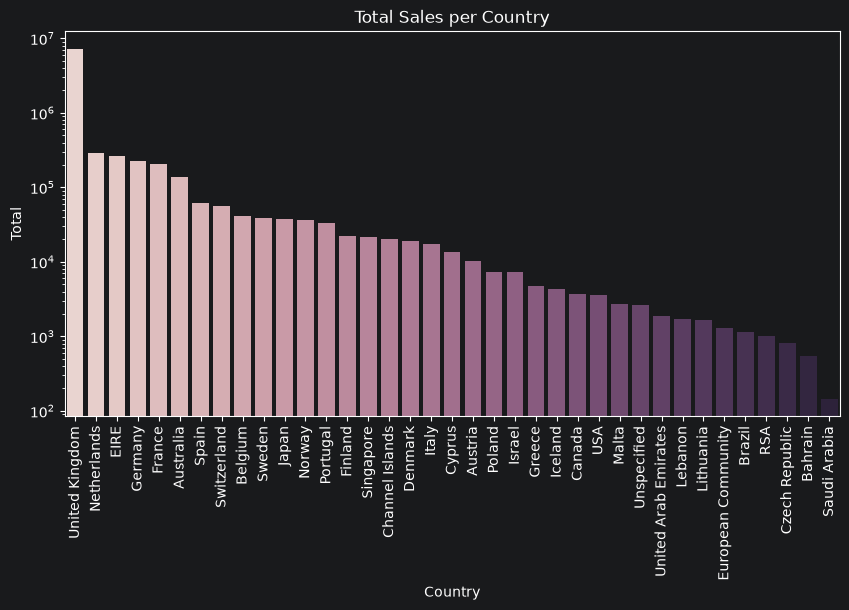

In [90]:
df["Total"] = df["Quantity"] * df["UnitPrice"]

data = (
    df.groupby("Country")["Total"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=data, x="Country", y="Total", hue=data.index, legend=False)
plt.xticks(rotation=90)
plt.title("Total Sales per Country")
plt.yscale("log")
plt.show()

# RFM

In [91]:
RFM = pd.DataFrame(df["CustomerID"].unique(), columns=["CustomerID"])

### Monetary

In [92]:
RFM = df.groupby("CustomerID")["Total"].sum().rename("Monetary").reset_index()
RFM

,CustomerID,Monetary
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40
...,...,...
4333,18280,180.60
4334,18281,80.82
4335,18282,178.05
4336,18283,2045.53


### Recency

In [93]:
last_sale = df.groupby("CustomerID")["InvoiceDate"].max()
RFM["LastSale"] = RFM["CustomerID"].map(last_sale)

snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)
RFM["Recency"] = (snapshot - RFM["LastSale"]).dt.days
RFM.drop(columns=["LastSale"], inplace=True)
RFM

,CustomerID,Monetary,Recency
0,12346,77183.60,326
1,12347,4310.00,3
2,12348,1797.24,76
3,12349,1757.55,19
4,12350,334.40,311
...,...,...,...
4333,18280,180.60,278
4334,18281,80.82,181
4335,18282,178.05,8
4336,18283,2045.53,4


### Frequency

In [94]:
frequency = df.groupby("CustomerID")["InvoiceNo"].nunique()
RFM["Frequency"] = RFM["CustomerID"].map(frequency)
RFM

,CustomerID,Monetary,Recency,Frequency
0,12346,77183.60,326,1
1,12347,4310.00,3,7
2,12348,1797.24,76,4
3,12349,1757.55,19,1
4,12350,334.40,311,1
...,...,...,...,...
4333,18280,180.60,278,1
4334,18281,80.82,181,1
4335,18282,178.05,8,2
4336,18283,2045.53,4,16


# RFM Visualization

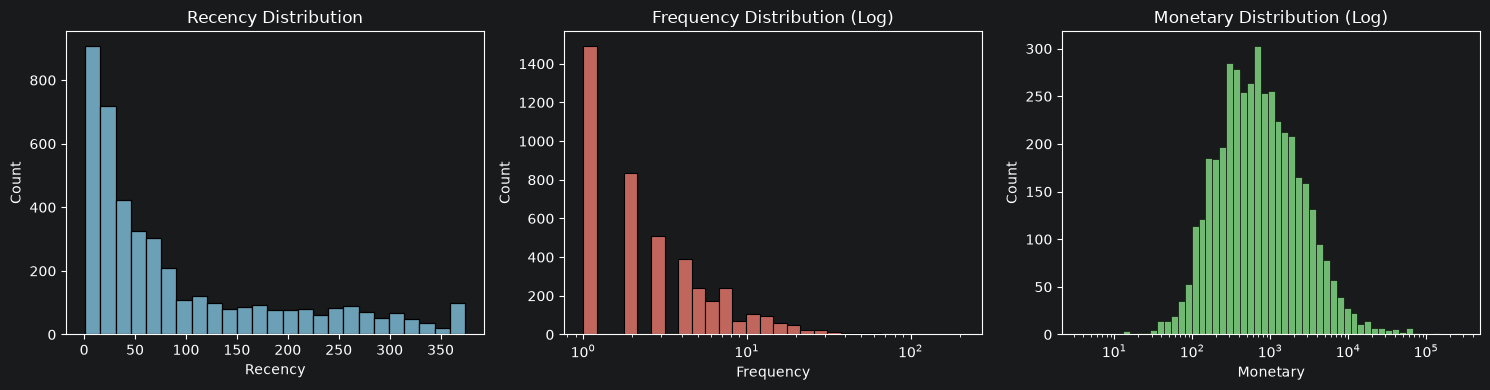

In [109]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

sns.histplot(RFM["Recency"], ax=axes[0], color="skyblue")
axes[0].set_title("Recency Distribution")

sns.histplot(RFM["Frequency"], ax=axes[1], color="salmon", log_scale=True)
axes[1].set_title("Frequency Distribution (Log)")

sns.histplot(RFM["Monetary"], ax=axes[2], color="lightgreen", log_scale=True)
axes[2].set_title("Monetary Distribution (Log)")

plt.tight_layout()
plt.show()

# Normalisation

In [111]:
RFM = (RFM - RFM.min()) / (RFM.max() - RFM.min())
RFM

,CustomerID,Monetary,Recency,Frequency
0,0.000000,0.275443,0.871314,0.000000
1,0.000168,0.015368,0.005362,0.028846
2,0.000337,0.006401,0.201072,0.014423
3,0.000505,0.006259,0.048257,0.000000
4,0.000673,0.001180,0.831099,0.000000
...,...,...,...,...
4333,0.998822,0.000631,0.742627,0.000000
4334,0.998990,0.000275,0.482574,0.000000
4335,0.999158,0.000622,0.018767,0.004808
4336,0.999327,0.007287,0.008043,0.072115
